In [137]:
import pandas as pd
print(pd.__version__)

3.0.6


In [138]:
df = pd.read_csv(r"C:\Users\PC\data-pipeline-project\OnlineRetail.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [139]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [140]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [141]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [142]:
df_clean = df[df['Quantity'] > 0]
print(f"Rows 9bal: {len(df)}")
print(f"Rows ba3d: {len(df_clean)}")

Rows 9bal: 541909
Rows ba3d: 531285


In [143]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f"Rows ba3d UnitPrice cleaning: {len(df_clean)}")

Rows ba3d UnitPrice cleaning: 530104


In [144]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='%d-%m-%Y %H:%M')
df_clean.info()

<class 'pandas.DataFrame'>
Index: 530104 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    530104 non-null  str           
 1   StockCode    530104 non-null  str           
 2   Description  530104 non-null  str           
 3   Quantity     530104 non-null  int64         
 4   InvoiceDate  530104 non-null  datetime64[us]
 5   UnitPrice    530104 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      530104 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 36.4 MB


In [145]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [146]:
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12


In [147]:
monthly_revenue = df_clean.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_revenue.columns = ['Month', 'Revenue']
print(monthly_revenue)

      Month      Revenue
0   2010-12   823746.140
1   2011-01   691364.560
2   2011-02   523631.890
3   2011-03   717639.360
4   2011-04   537808.621
5   2011-05   770536.020
6   2011-06   761739.900
7   2011-07   719221.191
8   2011-08   759138.380
9   2011-09  1058590.172
10  2011-10  1154979.300
11  2011-11  1509496.330
12  2011-12   638792.680


In [148]:
top_products = df_clean.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 78112.82
POSTAGE                                78101.88
RABBIT NIGHT LIGHT                     66964.99
Name: TotalPrice, dtype: float64


In [149]:
top_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_countries)

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64


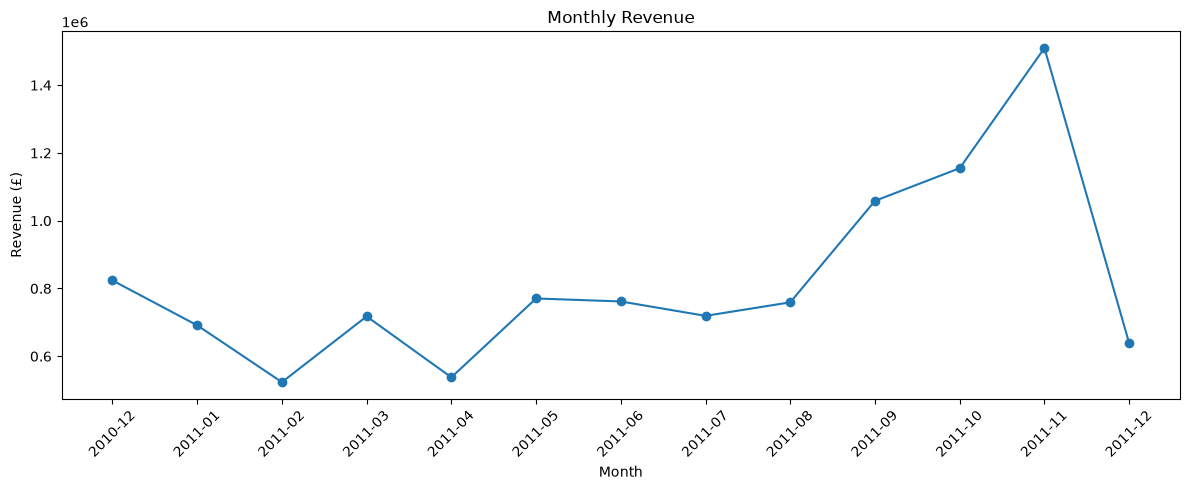

In [150]:
import matplotlib.pyplot as plt

monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue['Month'], monthly_revenue['Revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

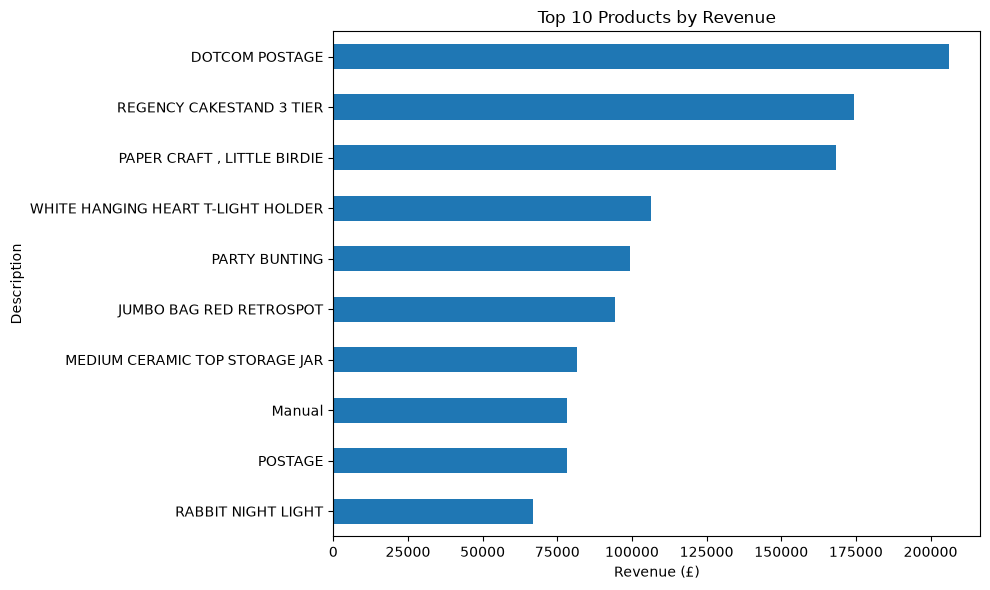

In [151]:
plt.figure(figsize=(10, 6))
top_products.plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

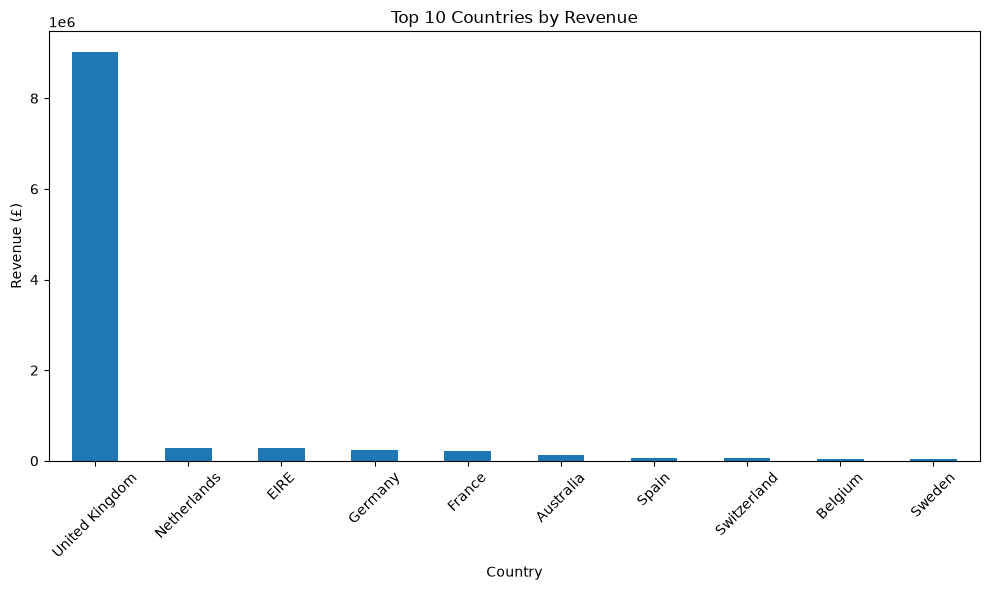

In [152]:
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()